# **Gazpar Meza y Vicente Olea**

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

sns.set_style("white")

# **DATA SET POKEMON**


**name**: The English name of the Pokemon

**japanese_name**: The Original Japanese name of the Pokemon

**pokedex_number**: The entry number of the Pokemon in the National Pokedex

**percentage_male**: The percentage of the species that are male. Blank if the Pokemon is genderless.

**type1**: The Primary Type of the Pokemon

**type2**: The Secondary Type of the Pokemon
classification: The Classification of the
Pokemon as described by the Sun and Moon Pokedex

**height_m**: Height of the Pokemon in metres

**weight_kg**: The Weight of the Pokemon in kilograms

**capture_rate**: Capture Rate of the Pokemon

**base_egg_steps**: The number of steps required to hatch an egg of the Pokemon

**abilities**: A stringified list of abilities that the Pokemon is capable of having

**experience_growth**: The Experience Growth of the Pokemon

**base_happiness**: Base Happiness of the Pokemon

**against_**?: Eighteen features that denote the amount of damage taken against an attack of a particular type

**hp**: The Base HP of the Pokemon

**attack**: The Base Attack of the Pokemon

**defense**: The Base Defense of the Pokemon

**sp_attack**: The Base Special Attack of the Pokemon

**sp_defense**: The Base Special Defense of the Pokemon

**speed**: The Base Speed of the Pokemon

**generation**: The numbered generation which the Pokemon was first introduced

**is_legendary**: Denotes if the Pokemon is legendary.

# Análisis inicial de la muestra



In [52]:
Pokedex = pd.read_csv("pokemon.csv")
pokemon = pd.read_csv("pokemon.csv")
Pokedex.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


Verificamos que todas las columnas tengan valores definidos

In [53]:
Pokedex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

In [54]:

print("TAMAÑO DATASET")
print(f"Tamaño del dataset (filas, columnas): {pokemon.shape}")

print("\n VALORES FALTANTES")
faltantes = pokemon.isnull().sum()
print(faltantes[faltantes > 0])





TAMAÑO DATASET
Tamaño del dataset (filas, columnas): (801, 41)

 VALORES FALTANTES
height_m            20
percentage_male     98
type2              384
weight_kg           20
dtype: int64


Notamos que, del total de 801 pokemones en el archivo, las columnas height_m, percentage_male, type2 y weight_kg presentan datos no definidos. La unica que tiene una explicacion "a priori" es type2, ya que es una mecanica intencional en los videojuegos el que un pokemon presente un solo tipo definido.

Por lo tanto, antes de formular nuestra pregunta de investigacion, debemos analizar el resto de estas faltas, para ello en los siguientes bloques de codigo estudiamos a que pokemones estan asociadas, buscando determinar si se le puede asociar una causa. Los estudios comprenden:

- Pokemones sin genero (percentage_male) definido
- Pokemones con altura (height_m) y peso (weight_m) no definidos

In [55]:
sin_genero = Pokedex[Pokedex['percentage_male'].isnull()]

normales_sin_genero = sin_genero[sin_genero['is_legendary'] == 0].head(5)
legendarios_sin_genero = sin_genero[sin_genero['is_legendary'] == 1].head(5)

print("=== Ejemplos de Pokémon sin género definido ===\n")
print("Normales:")
print(normales_sin_genero[['name', 'generation']].to_string(index=False))
print("\nLegendarios:")
print(legendarios_sin_genero[['name', 'generation']].to_string(index=False))

print(f"\n(Total sin género: {len(sin_genero)} -> "f"{(sin_genero['is_legendary']==0).sum()} normales, "f"{(sin_genero['is_legendary']==1).sum()} legendarios)")

=== Ejemplos de Pokémon sin género definido ===

Normales:
     name  generation
Magnemite           1
 Magneton           1
  Voltorb           1
Electrode           1
   Staryu           1

Legendarios:
    name  generation
Articuno           1
  Zapdos           1
 Moltres           1
  Mewtwo           1
     Mew           1

(Total sin género: 98 -> 35 normales, 63 legendarios)


La falta de datos en el genero se explica por la mecánica implantada en los videojuegos: ciertas especies estan clasificadas oficialmente como "genderless", por lo que no poseen un valor de proporcion macho/hembra aplicable. Esta categoría incluye entre los Pokémon normales a especies como Magnemite/Magneton y las lineas de Ditto y Porygon, y entre los legendarios a la gran mayoria de ellos. Esto explica porque el porcentaje de legendarios sin genero es notablemente mayor al de normales, la ausencia de género es la norma dentro de la categoría de legendarios.

In [56]:
mask_hw = Pokedex['height_m'].isnull() | Pokedex['weight_kg'].isnull()
faltantes_hw = Pokedex[mask_hw][['name', 'type1', 'type2', 'height_m', 'weight_kg', 'generation']]

print("\n\n=== Pokémon con height_m y/o weight_kg nulos ===\n")
print(faltantes_hw.to_string(index=False))
print(f"\nTotal: {len(faltantes_hw)} Pokémon afectados")



=== Pokémon con height_m y/o weight_kg nulos ===

     name    type1    type2  height_m  weight_kg  generation
  Rattata   normal     dark       NaN        NaN           1
 Raticate   normal     dark       NaN        NaN           1
   Raichu electric electric       NaN        NaN           1
Sandshrew   ground      ice       NaN        NaN           1
Sandslash   ground      ice       NaN        NaN           1
   Vulpix     fire      ice       NaN        NaN           1
Ninetales     fire      ice       NaN        NaN           1
  Diglett   ground   ground       NaN        NaN           1
  Dugtrio   ground   ground       NaN        NaN           1
   Meowth   normal     dark       NaN        NaN           1
  Persian   normal     dark       NaN        NaN           1
  Geodude     rock   ground       NaN        NaN           1
 Graveler     rock   ground       NaN        NaN           1
    Golem     rock   ground       NaN        NaN           1
   Grimer   poison   poison      

A diferencia del genero, la falta de datos en height_m y weight_kg no encuentra una explicacion en las mecanicas del juego, por lo que concluimos que existe un error en el archivo, probablemente ocurrido durante la construccion de la tabla.

Esto conllevó a que nuestra pregunta de investigación no involucre directamente estas variables. Por lo tanto, nosotros proponemos estudiar:

# ¿Los pokemon se vuelven más fuertes a medida que avanzan las generaciones?


**¿Qué representa una observación?**

Cada fila de la muestra es un Pokémon individual, con un total de 801 pokémones correspondientes desde la primera hasta la séptima generación.

**¿Qué población está siendo estudiada?**

El universo completo de especies de Pokémon existentes hasta la generación 7. No es una muestra aleatoria, es un censo completo de todas las especies canónicas.

**¿Cuáles son los principales features?**



*   **Identificación**: name, pokedex_number, generation, type1/type2

*   **Estadísticas de combate**: hp, attack, defense, sp_attack, sp_defense, speed, base_total (la suma de las 6 anteriores)



*   **Físicas**: height_m, weight_kg
*   **Otras**: is_legendary, capture_rate, base_egg_steps, percentage_male, las 18 columnas against_* (efectividad de tipos)


**¿Qué tipo de información contiene cada una?**



*   **Numéricas continuas**: stats de combate, altura, peso
*   **Categóricas**: type1, type2, classfication, generation


*   **Binaria**: is_legendary


**¿Existen valores faltantes, extremos o problemas de calidad?**



*   **type2**: Faltan 384 datos de esta categoría (~48%). Esto es normal debido a que muchos Pokémon tienen un solo tipo, no es un error

*   **percentage_male**: 98 datos faltantes, que corresponden a especies sin un género definido


*   **height_m y weight_kg**: 20 datos faltantes de cada uno

*   **base_total**: Hay valores extremos (min 180, máx 780)

**¿hay alguna limitación importante en la forma en que se obtuvieron los datos?**

Sí. La principal limitación son los errores ocurridos durante la extracción original de los datos, lo cual queda en evidencia con los 20 valores faltantes injustificados en las columnas de peso y altura. Adicionalmente, el dataset está desactualizado, ya que representa un censo estático que solo abarca hasta la Generación 7 (801 Pokémon), dejando fuera a cientos de criaturas más recientes.










# **Gráfico 1**

Gráfico de barras con la cantidad de Pokémon introducidos por generación.

/tmp/ipykernel_2605/2666655082.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pokemon, x='generation', palette='viridis')


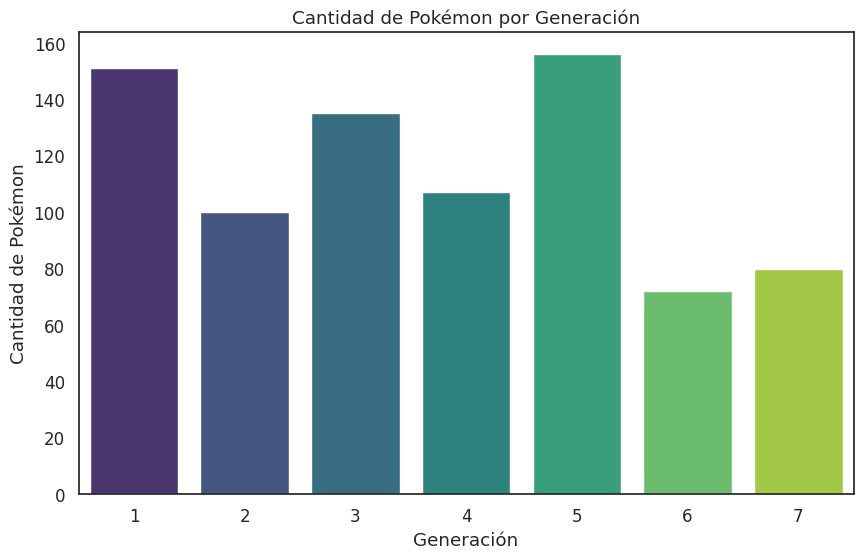

In [57]:

plt.figure(figsize=(10, 6))
sns.countplot(data=pokemon, x='generation', palette='viridis')
plt.title('Cantidad de Pokémon por Generación')
plt.xlabel('Generación')
plt.ylabel('Cantidad de Pokémon')
plt.show()

Este gráfico nos permite entender el tamaño de nuestra muestra por grupo. Observamos que la introducción de nuevas especies no es constante, las generaciones 1 y 5 aportaron la mayor cantidad (alrededor de 150 cada una), mientras que la generación 6 fue la que menos Pokémon introdujo (72). Esto es importante porque las generaciones con menos integrantes podrían ser más susceptibles a variaciones bruscas en sus promedios si incluyen proporciones inusuales de Pokémon muy fuertes o muy débiles.

A continuación, comenzamos analizando el poder total (base_total) promedio de cada generacion Pokemon.

Debido a que esta variable puede flucturar considerablemente dentro de una misma generacion, se incluyen 3 vistas: barras simples, barras con desviación estándar, y boxplot.

# **Gráfico 2**

Poder total por generación (barras simples a la izquierda, barras con desviación estándar al medio, y boxplot a la derecha).

                  mean         std  count
generation                               
1           416.251656  112.273370    151
2           413.180000  120.762676    100
3           420.022222  136.620428    135
4           451.177570  122.586266    107
5           427.038462  103.846902    156
6           437.611111  121.989789     72
7           448.162500  115.986189     80


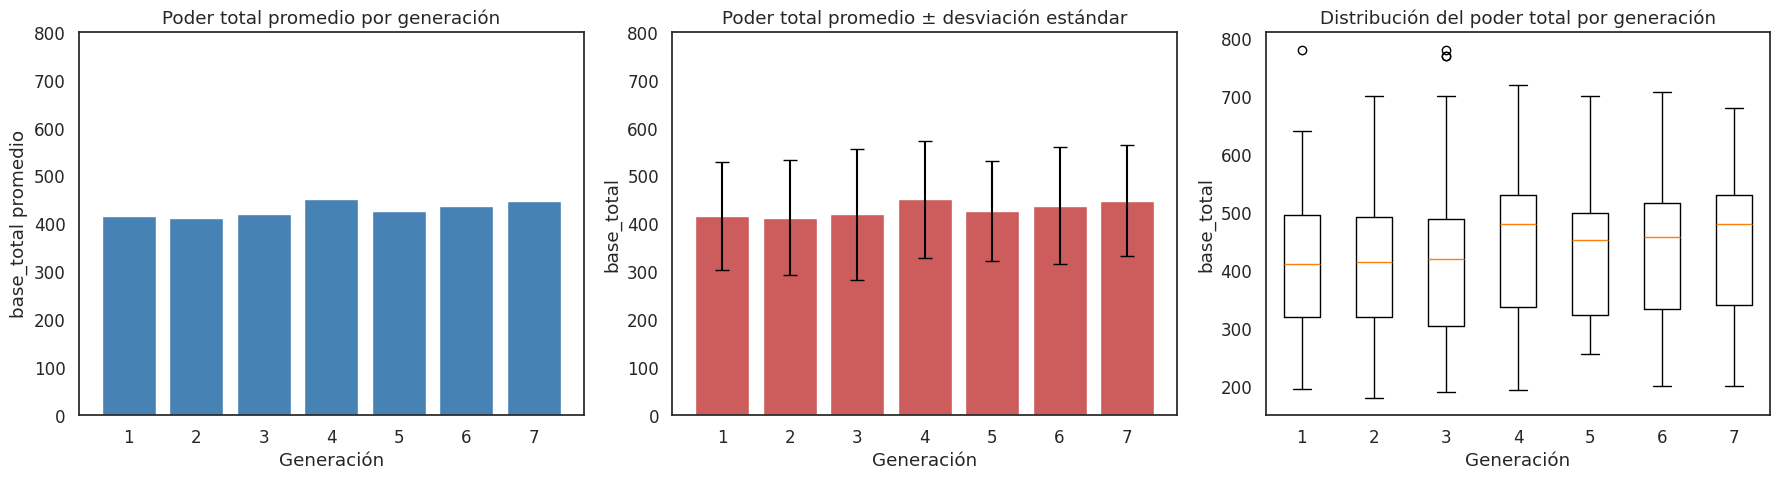

In [58]:
# --- Calcular estadísticos por generación ---
stats_gen = Pokedex.groupby('generation')['base_total'].agg(['mean', 'std', 'count'])
print(stats_gen)

# --- Graficos ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Barras simples (promedio)
axes[0].bar(stats_gen.index, stats_gen['mean'], color='steelblue')
axes[0].set_title('Poder total promedio por generación')
axes[0].set_xlabel('Generación')
axes[0].set_ylabel('base_total promedio')
axes[0].set_ylim(0,800)

# 2) Barras con barra de error (desviación estándar)
axes[1].bar(stats_gen.index, stats_gen['mean'], yerr=stats_gen['std'],
            capsize=5, color='indianred')
axes[1].set_title('Poder total promedio ± desviación estándar')
axes[1].set_xlabel('Generación')
axes[1].set_ylabel('base_total')
axes[1].set_ylim(0,800)

# 3) Boxplot (distribución completa por generación)
data_por_gen = [Pokedex[Pokedex['generation'] == g]['base_total'] for g in sorted(Pokedex['generation'].unique())]
axes[2].boxplot(data_por_gen, tick_labels=sorted(Pokedex['generation'].unique()))
axes[2].set_title('Distribución del poder total por generación')
axes[2].set_xlabel('Generación')
axes[2].set_ylabel('base_total')

plt.tight_layout()
#plt.savefig('comparacion_generaciones.png', dpi=600)

Cualitativamente, el primer grafico (barras simples) sugiere un leve aumento del poder total promedio a lo largo de las generaciones, aproximadamente de 416 en la generación 1 a 451 en la generación 4. Sin embargo esto no es monotono, ya que cae a 413 desde la generacion 1 a la 2, y vuelve a bajar a 427 desde la generacion 4 a la 5, para finalmente volver a subir en las generaciones 6 y 7.

En el segundo grafico al agregar la desviacion estandar se pone en perspectiva esa diferencia. La desviacion estandar dentro de cada generacion oscila entre 104 y 137 puntos aproximadamente, muy por encima de la diferencia maxima entre promedios (siendo 35 puntos entre la generación 2 y la 4). En otras palabras, la variabilidad de poder total entre pokemones de una misma generacion es varias veces mayor que la variabilidad entre generaciones, las barras de error se superponen casi por completo entre todas las generaciones.

El ultimo grafico (boxplot) confirma esto con mayor detalle, aunque las medianas muestran un desplazamiento ascendente similar al de las medias, las cajas se solapan fuertemente entre todas las generaciones, sin que ninguna se distinga claramente del resto. Mas aun es destacable la presencia de outliers superiores en las generaciones 1 y 3, que podrian estar señalando la influencia de un subgrupo particular de pokemones con estadisticas mucho mas altas que el resto.

En conjunto, estos graficos indican que visualmente no es posible afirmar con confianza que el poder total de los pokemones aumente de forma consistente con las generaciones, la dispersion interna de cada generacion es demasiado grande frente a la diferencia entre sus promedios.

Dado que el poder total es la suma de las estadisticas individuales (ataque, defensa, velocidad, etc.) de un pokemon, realizar un analisis de cada una de forma separada nos permitiria identificar comportamientos ocultos entre si. Por ejemplo, el aumento en una podria compensar una disminucion en otra sin que se refleje una variacion en el poder total. Es por esto que el siguiente paso es descomponer y estudiar la evolución de cada estadística por separado.

# **Gráfico 3**

Gráfico de líneas con la evolución promedio de cada estadística por generación (incluye todos los Pokémon).

                   hp                attack               defense             \
                 mean        std       mean        std       mean        std   
generation                                                                     
1           64.344371  28.593483  74.529801  29.863647  70.079470  29.146875   
2           70.980000  31.230321  69.960000  32.003762  71.790000  38.015227   
3           65.666667  25.182320  77.185185  35.719718  72.637037  34.915806   
4           73.102804  24.654187  82.672897  33.723564  76.168224  30.980361   
5           70.314103  21.631758  80.557692  29.482469  71.961538  23.505904   
6           71.111111  27.304519  76.527778  31.033817  73.555556  29.286294   
7           70.575000  28.286408  84.637500  32.247557  78.012500  29.879290   

            sp_attack            sp_defense                 speed             
                 mean        std       mean        std       mean        std  
generation                               

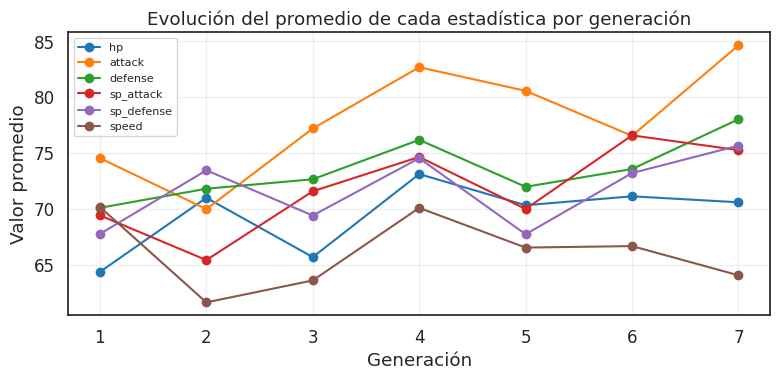

In [59]:
stats_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

# --- Tabla resumen: promedio y std de cada stat por generación ---
resumen = Pokedex.groupby('generation')[stats_cols].agg(['mean', 'std'])
print(resumen)

# --- Gráfico 1: líneas de promedio por estadística, todas juntas ---
fig, ax = plt.subplots(figsize=(8, 4))
medias = Pokedex.groupby('generation')[stats_cols].mean()
for col in stats_cols:
    ax.plot(medias.index, medias[col], marker='o', label=col)
ax.set_xlabel('Generación')
ax.set_ylabel('Valor promedio')
ax.set_title('Evolución del promedio de cada estadística por generación')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('evolucion_stats_lineas.png', dpi=600)

# **Gráfico 4**

Panel de seis boxplots con la distribución de cada estadística individual por generación.

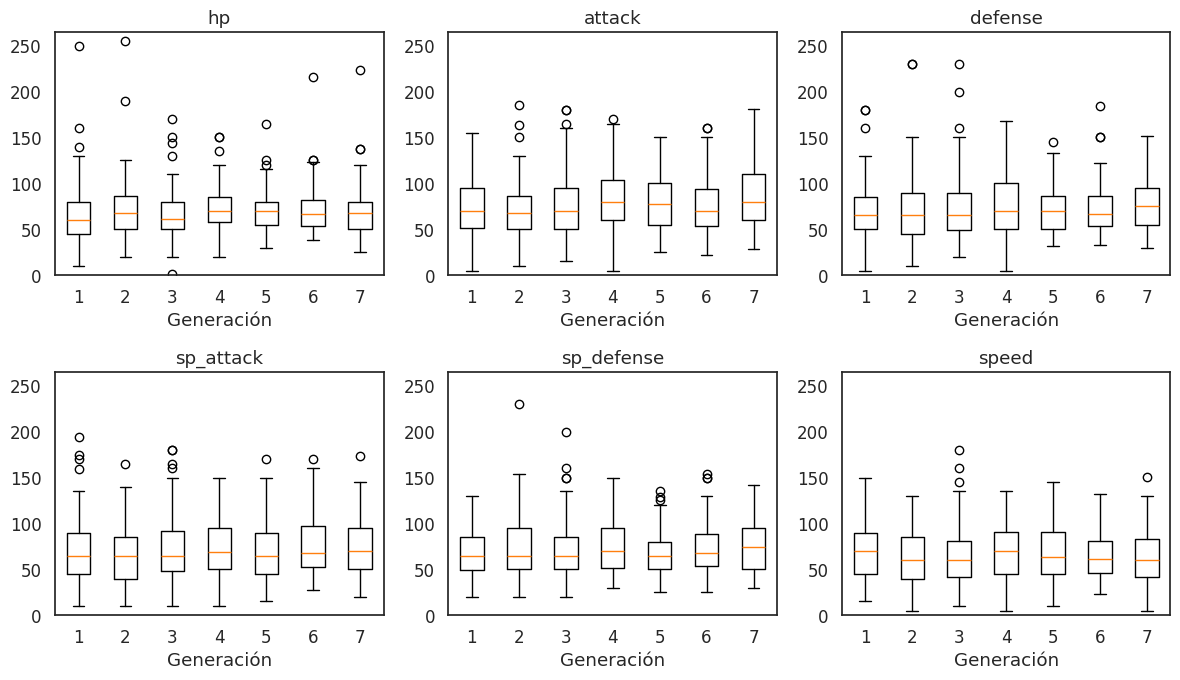

In [60]:

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
generaciones = sorted(Pokedex['generation'].unique())

for i, col in enumerate(stats_cols):
    data = [Pokedex[Pokedex['generation'] == g][col] for g in generaciones]
    axes[i].boxplot(data, tick_labels=generaciones)
    axes[i].set_title(col)
    axes[i].set_xlabel('Generación')
    axes[i].set_ylim(0,265)

plt.tight_layout()


Un estadistico de utilidad para complementar cuantitativamente el analisis visual de los graficos es el coeficiente de Pearson, el cual mide la fuerza y direccion de una posible relacion lineal entre la generación (tratada como variable numérica) y cada estadistica individual. Su valor va de -1 a +1: valores cercanos a 0 indican ausencia de relacion lineal, mientras que valores cercanos a +1 o -1 indican una relacion fuerte, ya sea creciente o decreciente.

In [61]:
correlaciones = Pokedex[stats_cols + ['generation']].corr(method="pearson")['generation'].drop('generation')
print("\nCorrelación de Pearson entre generación y cada estadística:")
print(correlaciones.sort_values(ascending=False))


Correlación de Pearson entre generación y cada estadística:
attack        0.101375
hp            0.074065
sp_attack     0.070146
defense       0.057603
sp_defense    0.048711
speed        -0.019914
Name: generation, dtype: float64


Visualmente, en el **gráfico 3** se evidencia una tendencia al aumento para las estadisticas de attack (74 a 84), defense (70 a 78), sp_attack (69 a 75) y sp_defense (67 a 76). En cambio las demas no presentan esto con el paso de las generaciones, si no que, o se mantienen realtivamente constante (como el caso de hp), o tienen una tendencia a la disminucion (speed, de 70 a 64).

Pasando al boxplot (**gráfico 4**) esta tendencia se pierde fuerza consierablemente, las medianas se mantienen mucho mas estables entre generaciones para todas las estadisticas, asi como que las cajas se superponen entre si, de forma similar a lo observado con el poder total. Lo mas llamativo aqui es la mayor presencia de outliers varias de las estadisticas (siendo especialmente marcada en hp), lo que al igual que con el poder total, refuerza la idea de que existe un subgrupo que esta inflando los promedios y generando la apariencia de tendencia que se disuelve al mirar la distribución completa. La explicacion a este efecto se podria encontrar en los pokemones legendarios, los cuales fueron diseñados en los videojuegos para presentar estadisticas intrinsecamente superiores a las de los pokemones normales, dejando abierta la pregunta de cuanto de la tendencia observada responde a este subgrupo particular y no a un cambio real en el conjunto de los pokemones.

Esto se confirma con el coeficiente de Pearson, al ser cercano a 0 en todas las estadisticas, indica de que no existe una correlacion y asociacion lineal entre las variables y paso de las generaciones.

A continuacion hacemos un sub-analisis: ¿Son los outliers de cada estadistica mayormente pokemones legendarios? Si la respuesta resultara ser afirmativa, se requerira repetir la comparacion de estadisticas, pero esta vez aislando a los pokemones legendarios de la muestra, en cada generacion.

In [62]:
stats_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_total']

print("¿Qué porcentaje de los outliers de cada estadistica corresponden a pokemones legendarios?")

# Como referencia: que porcentaje de los pokemones son legendarios en el dataset completo
pct_total = Pokedex['is_legendary'].mean() * 100
print(f"\n(Para referencia: los legendarios son solo el {pct_total:.1f}% de todos los Pokémon)\n")

for col in stats_cols:
    q1, q3 = Pokedex[col].quantile(0.25), Pokedex[col].quantile(0.75)
    iqr = q3 - q1
    upper_outliers = Pokedex[Pokedex[col] > q3 + 1.5 * iqr]
    if len(upper_outliers) > 0:
        pct_legendary = upper_outliers['is_legendary'].mean() * 100
        print(f"{col}: {len(upper_outliers)} outliers superiores, {pct_legendary:.1f}% son legendarios")
    else:
        print(f"{col}: sin outliers superiores")

# --- Comparación legendarios vs no-legendarios, por generación ---
resumen_leg = Pokedex.groupby(['generation', 'is_legendary'])[stats_cols].mean()
print("\n\nPromedios por generación y estatus legendario:")
print(resumen_leg)


¿Qué porcentaje de los outliers de cada estadistica corresponden a pokemones legendarios?

(Para referencia: los legendarios son solo el 8.7% de todos los Pokémon)

hp: 21 outliers superiores, 33.3% son legendarios
attack: 5 outliers superiores, 60.0% son legendarios
defense: 11 outliers superiores, 18.2% son legendarios
sp_attack: 10 outliers superiores, 60.0% son legendarios
sp_defense: 6 outliers superiores, 66.7% son legendarios
speed: 6 outliers superiores, 33.3% son legendarios
base_total: sin outliers superiores


Promedios por generación y estatus legendario:
                                 hp      attack     defense   sp_attack  \
generation is_legendary                                                   
1          0              63.287671   73.486301   69.431507   67.404110   
           1              95.200000  105.000000   89.000000  127.800000   
2          0              68.946809   68.095745   70.042553   63.244681   
           1             102.833333   99.166667   9

# **Gráfico 5**

Gráfico de barras dobles comparando el poder total promedio entre Legendarios y No Legendarios por generación.


Diferencia (Legendario - No legendario) en base_total, por generación:
generation
1    214.863014
2    216.475177
3    265.656000
4    201.801964
5    200.433566
6    258.606061
7    135.293184
Name: diferencia, dtype: float64

Número de legendarios por generación:
generation
1     5
2     6
3    10
4    13
5    13
6     6
7    17
dtype: int64


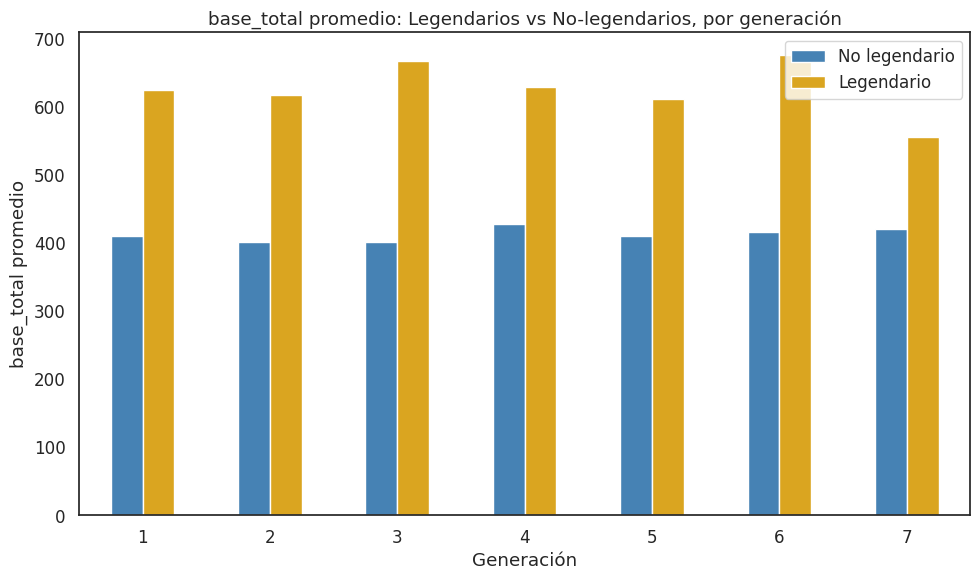

In [63]:

pivot = Pokedex.groupby(['generation', 'is_legendary'])['base_total'].mean().unstack()
pivot.columns = ['No legendario', 'Legendario']

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='bar', ax=ax, color=['steelblue', 'goldenrod'])
ax.set_xlabel('Generación')
ax.set_ylabel('base_total promedio')
ax.set_title('base_total promedio: Legendarios vs No-legendarios, por generación')
ax.legend(title='')
plt.xticks(rotation=0)
plt.tight_layout()

# --- 4) ¿La "ventaja" de ser legendario crece con las generaciones? ---
pivot['diferencia'] = pivot['Legendario'] - pivot['No legendario']
print("\nDiferencia (Legendario - No legendario) en base_total, por generación:")
print(pivot['diferencia'])

# --- 5) Conteo de legendarios introducidos por generación ---
print("\nNúmero de legendarios por generación:")
print(Pokedex[Pokedex['is_legendary'] == 1].groupby('generation').size())

Como se sospechaba, en la mayoria de las estadisticas los pokemones legendarios representan un porcentaje de outliers muy superior a su proporcion real en los datos (siendo un 8.7% del total de pokemones): 60% en attack, 60% en sp_attack, 66.7% en sp_defense, y aproximadamente un 33% en hp y speed. La unica excepcion es defense, donde los legendarios comprenden solo el 18.2% de los outliers.

Algo curioso a destacar es base_total no presento outliers al analizar el dataset completo de forma global (a diferencia del boxplot por generaciones mostrado anteriormente), dado que la presencia numerosa de legendarios (70 en total) ya eleva el umbral de corte lo suficiente como para absorber sus valores dentro del rango esperado.

Esto confirma que los pokemones legendarios tienen estadisticas base intrinsecamente mas altas que los normales, y que son ellos quienes explican gran parte de la dispersion y extremos observados en los graficos anteriores. Esto se corrobora al comparar el base_total entre pokemones normales y legendarios en cada generacion: los legendarios superan ampliamente a los demas en todas las generaciones, sin excepcion.

Por lo tanto, para responder con precision a nuestra pregunta, es necesario repetir el analisis anterior, pero esta vez excluyendo a los pokemones legendarios de la muestra para asi poder aislar el comportamiento de los pokemoens normales.

Previamente calculamos unicamente el "r-valor" del coeficiente de Pearson, pero esta vez incluiremos tambien su "p-valor" asociado. Este responde a una pregunta distinta, ya no buscamos saber "¿Que tan fuerte es la relacion entre una estadistica y las generaciones?", sino que "¿Es esta relacion confiable, o pudo haber salido asi solo por casualidad con los pokemones que nos tocaron en la muestra?". Por convencion, si p es menor a 0.05 se considera que la relacion es real y no un accidente de los datos. En caso contrario, no se puede descartar que sea pura casualidad.

# **Gráfico 6 y 7**
Gráfico de líneas de estadísticas excluyendo legendarios (arriba) y líneas comparando el poder total con vs sin legendarios (abajo).

Promedios por generación (excluyendo legendarios):

                   hp                attack               defense             \
                 mean        std       mean        std       mean        std   
generation                                                                     
1           63.287671  28.465820  73.486301  29.510311  69.431507  29.356291   
2           68.946809  31.062326  68.095745  31.772738  70.042553  38.271221   
3           64.080000  25.129535  74.080000  33.349227  68.768000  31.852770   
4           69.585106  22.895935  79.234043  33.530094  72.382979  30.573059   
5           68.265734  21.097010  77.608392  28.289259  70.000000  23.093807   
6           67.303030  19.356549  71.484848  26.358617  71.136364  28.734801   
7           64.761905  19.228435  80.238095  28.674319  74.539683  28.006235   

            sp_attack            sp_defense                 speed             \
                 mean        std       mean        std       mean  

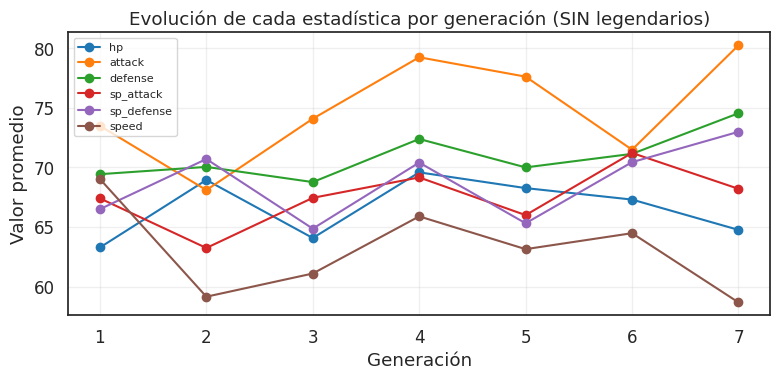

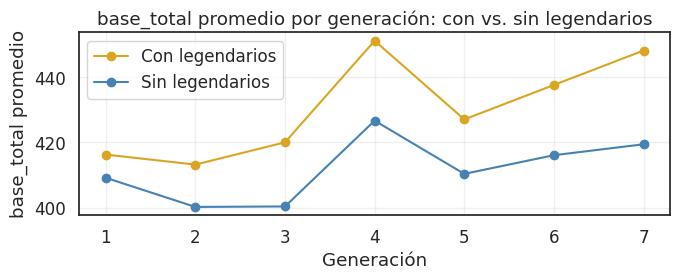

In [64]:
"""
Análisis de power creep EXCLUYENDO legendarios: base_total y cada estadística
individual, comparadas entre generaciones, solo para Pokémon "normales".
"""

Pokedex_normal = Pokedex[Pokedex['is_legendary'] == 0].copy()

stats_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_total']


resumen = Pokedex_normal.groupby('generation')[stats_cols].agg(['mean', 'std'])
print("Promedios por generación (excluyendo legendarios):\n")
print(resumen)


medias = Pokedex_normal.groupby('generation')[stats_cols].mean()

fig, ax = plt.subplots(figsize=(8, 4))
for col in ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']:
    ax.plot(medias.index, medias[col], marker='o', label=col)
ax.set_xlabel('Generación')
ax.set_ylabel('Valor promedio')
ax.set_title('Evolución de cada estadística por generación (SIN legendarios)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('evolucion_stats_sin_legendarios.png', dpi=600)


medias_con = Pokedex.groupby('generation')['base_total'].mean()
medias_sin = Pokedex_normal.groupby('generation')['base_total'].mean()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(medias_con.index, medias_con.values, marker='o', label='Con legendarios', color='goldenrod')
ax.plot(medias_sin.index, medias_sin.values, marker='o', label='Sin legendarios', color='steelblue')
ax.set_xlabel('Generación')
ax.set_ylabel('base_total promedio')
ax.set_title('base_total promedio por generación: con vs. sin legendarios')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig('base_total_con_vs_sin_legendarios.png', dpi=600)

In [65]:
Pokedex_normal = Pokedex[Pokedex['is_legendary'] == 0].copy()

stats_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_total']

print(f"{'Estadística':<12}{'Pearson r':<12}{'p-valor':<12}{'¿Significativo?'}")
print("-" * 50)

for col in stats_cols:
    r, p = stats.pearsonr(Pokedex_normal['generation'], Pokedex_normal[col])
    sig = "Sí (p<0.05)" if p < 0.05 else "No"
    print(f"{col:<12}{r:>+.3f}      {p:.4f}      {sig}")

Estadística Pearson r   p-valor     ¿Significativo?
--------------------------------------------------
hp          +0.036      0.3274      No
attack      +0.069      0.0640      No
defense     +0.037      0.3199      No
sp_attack   +0.029      0.4321      No
sp_defense  +0.039      0.2957      No
speed       -0.055      0.1392      No
base_total  +0.042      0.2594      No


Con estos **graficos 6 y 7**, al comparar las curvas de cada estadistica, con y sin los pokemones legendarios, notamos que no todas se comportan igual. Por ejemplo, attack, defense y sp_defense mantienen una forma de tendencia ascendente tal y como ocurria en el analisis anterior (solo que esta vez se desplazo hacia valores más bajos, como es de esperarse al remover al subgrupo con estadisticas intrinsecamente mas altas). En cambio, hp y sp_attack pierden gran parte de su tendencia al aumento y quedan practicamente planas, mientras que speed acentua su caida. Esto sugiere que buena parte del aumento aparente en hp y sp_attack observado en el analisis anterior se debia, en efecto, a la influencia de los pokemones legendarios, y no a un cambio real en el conjunto general de pokemones. Lo mismo se observa al comparar el poder total (base_total) de legendarios y no-legendarios: ambas curvas mantienen una forma similar entre si, pero los legendarios presentan, por diseño de los videojuegos, valores sistematicamente mas altos en cada generacion.

Esto se confirma cuantitativamente con el coeficiente de Pearson para todas las estadisticas. El valor de r se mantiene cercano a 0 (variando entre -0.055 y +0.069), y ninguno alcanza una significancia estadistica convencional (se tuvo que p > 0.05 en todos los casos, siendo attack el mas cercano con 0.064). Esto indica que ninguna estadistica individual, ni siquiera el poder total, muestra una correlacion lineal confiable con el paso de las generaciones una vez excluidos los pokemones legendarios de la muestra.

# **Figura clave**

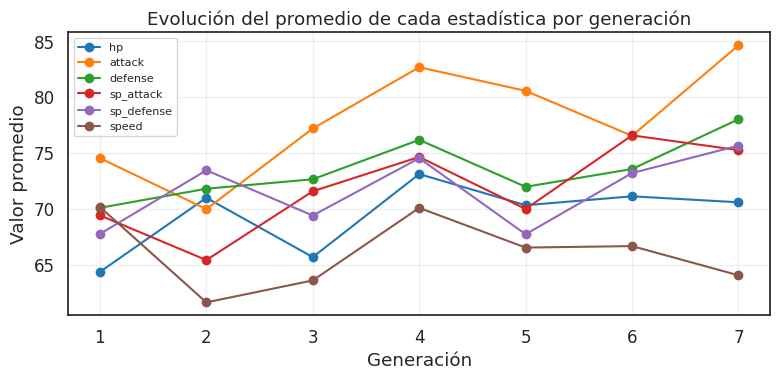

In [66]:
stats_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']



fig, ax = plt.subplots(figsize=(8, 4))
medias = Pokedex.groupby('generation')[stats_cols].mean()
for col in stats_cols:
    ax.plot(medias.index, medias[col], marker='o', label=col)
ax.set_xlabel('Generación')
ax.set_ylabel('Valor promedio')
ax.set_title('Evolución del promedio de cada estadística por generación')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()




Elegimos el gráfico de **evolución de cada estadística por generación** como nuestra figura clave.

**¿Qué pregunta responde?** Es la figura que descompone directamente nuestra pregunta de
investigación. En vez de mirar solo el poder total (una suma que puede ocultar compensaciones
entre estadísticas), muestra cómo evoluciona cada estadística de combate por separado a lo largo
de las 7 generaciones.

**¿Qué patrón muestra?** El Ataque muestra la tendencia ascendente más clara y consistente
(de 74.5 en Gen 1 a 84.6 en Gen 7), acompañado de subidas más leves en Defensa (70.1 hasta 78.0) y
Defensa Especial (67.7 hasta 75.6). En cambio, la Velocidad no sigue esa dirección, parte en 70.2,
baja fuertemente en Gen 2 (61.6) y termina en 64.0 en Gen 7 (más baja que al inicio). HP y
Ataque Especial se mantienen relativamente estables, con variaciones menores sin una tendencia
definida.

**¿Por qué es importante?** Porque revela realmente lo que ocurre con con respecto al poder total de generación en generación. Demuestra que la aparente estabilidad del poder total esconde comportamientos internos en las estadísticas de combate: las nuevas generaciones tienen mayor ataque y defensa en promedio, pero vemos un decaimiento en generaciones de la velocidad. Esta figura es clave porque prueba que si pueden haber alzas o decaimiento en algunos estadísticos de poder a medida que avanzan las generaciones. Adicionalmente, y de forma implicita para el analisis posterior realizado, este grafico muestra como los pokemones legendarios conllevan a "inflar" los valores, demostrando como es necesario aislar subgrupos de pokemones para obtener resultados mas igualitarios.

#  **¿Los pokemon se vuelven más fuertes a medida que avanzan las generaciones?**
**Conclusión**



Con todo esto, teniendo ahora una muestra libre de la distorsion que introducian los pokemones legendarios, podemos establecer una conclusion y respuesta a nuestra pregunta de investigacion:

**Los pokemones no se vuelven mas fuertes, de forma estadisticamente sostenida, a medida que avanzan las generaciones entre la 1 y la 7.**

Si bien attack muestra un indicio debil de tendencia al aumento, este no alcanza a ser estadisticamente significativo, por lo que no constituye evidencia suficiente para afirmar la existencia de que el "power creep" sea real. Por supuesto, existen muchas mas generaciones de pokemones (9 actualmente y una 10 en desarrollo), por lo tanto, los analisis y conclusiones presentados en este trabajo deben considerarse como preliminares y acotados al rango de generaciones disponible en este dataset, sin que puedan extrapolarse automaticamente a la franquicia completa. Seria necesario actualizar el dataset con los datos de estas generaciones mas recientes para determinar si las conclusiones presentadas aqui se mantienen, o si surge una tendencia mas clara en los juegos mas recientes de Pokemon.

# Resultado más inesperado

De todo el analisis y los graficos obtenidos, destacamos el boxplot de las estadisticas individuales con los pokemones legendarios incluidos como nuestro hallazgo menos esperado. En un principio no nos esperabamos que un grupo tan pequeño de pokemones (apenas un 8.7% de la muestra) pudiera concentrar una proporcion tan alta de los valores extremos en casi todas las estadisticas. Incluso, este hallazgo termino marcando el rumbo del resto del trabajo, obligandonos a repetir el analisis con una muestra "mas limpia", sin legendarios, para responder correctamente la pregunta de investigacion.

**Observacion:** El boxplot mostraba la distribucion de cada estadistica individual a lo largo de las generaciones, y presentaba una cantidad considerable de outliers superiores en casi todas ellas (especialmente en hp), mucho mas de lo que esperariamos si las estadisticas se distribuyeran de forma homogenea entre todos los pokemones.

**Hipotesis:** Inicialmente propusimos que estos outliers correspondian mayoritariamente a pokemones legendarios, dado que este subgrupo presenta estadisticas intrinsecamente superiores a las de los pokemones comunes.

**Evidencia adicional:** Para evaluar esta hipotesis, calculamos que porcentaje de los outliers de cada estadistica correspondia efectivamente a pokemones legendarios. Los resultados confirmaron la hipotesis, los legendarios representaron entre el 33% y el 67% de los outliers, dependiendo de la estadistica (con la excepcion de defense, donde su participacion fue menor, siendo cercana al 18%). Esto nos llevo a repetir el analisis completo descartando a todos los pokemones que cumplieran con que is_legendary = 1 del resto de la muestra, para obtener una comparacion más justa entre generaciones.

# **Desafío: ¿Dos Pokémon con un poder total similar son necesariamente similares?**

La pregunta puede interpretarse en distintos sentidos. Nosotros decidimos investigarla en la dimensión de similitud en las estadísticas de combate (ataque, defensa, etc.), que es el sentido de 'poder' .

# **Gráfico 8**

Para explorar la primera dimensión, graficamos Ataque contra Defensa de todos los Pokémon, coloreando cada uno según su poder total (BST) como se observa a continuación:

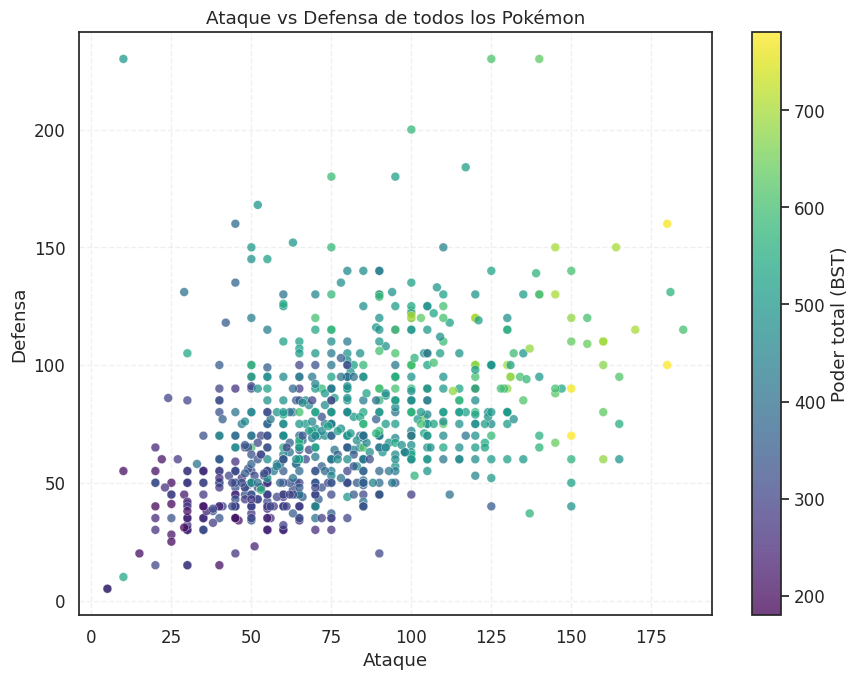

✓ Gráfico 2 guardado


In [67]:
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(pokemon['attack'], pokemon['defense'],
                     c=pokemon['base_total'], cmap='viridis',
                     s=40, alpha=0.75, edgecolors='white', linewidths=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Poder total (BST)')

ax.set_xlabel('Ataque')
ax.set_ylabel('Defensa')
ax.set_title('Ataque vs Defensa de todos los Pokémon')
ax.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig('g2_scatter_bst.png', dpi=160, bbox_inches='tight')
plt.show()
print("✓ Gráfico 2 guardado")

Se observa que para los grupos de un mismo color (poder total) aparecen relativamente dispersos prácticamente en todo el gráfico: hay Pokémon de poder total medio (verdes) tanto en la esquina de alta defensa/bajo ataque como en la de alto ataque/baja defensa. Esto sugiere que el poder total no condiciona a ningún perfil particular de combate.

# **Gráfico 9, 10 y 11**

Histogramas de la distribución de cada estadística filtrados por nivel de poder (Bajo, Medio y Alto).

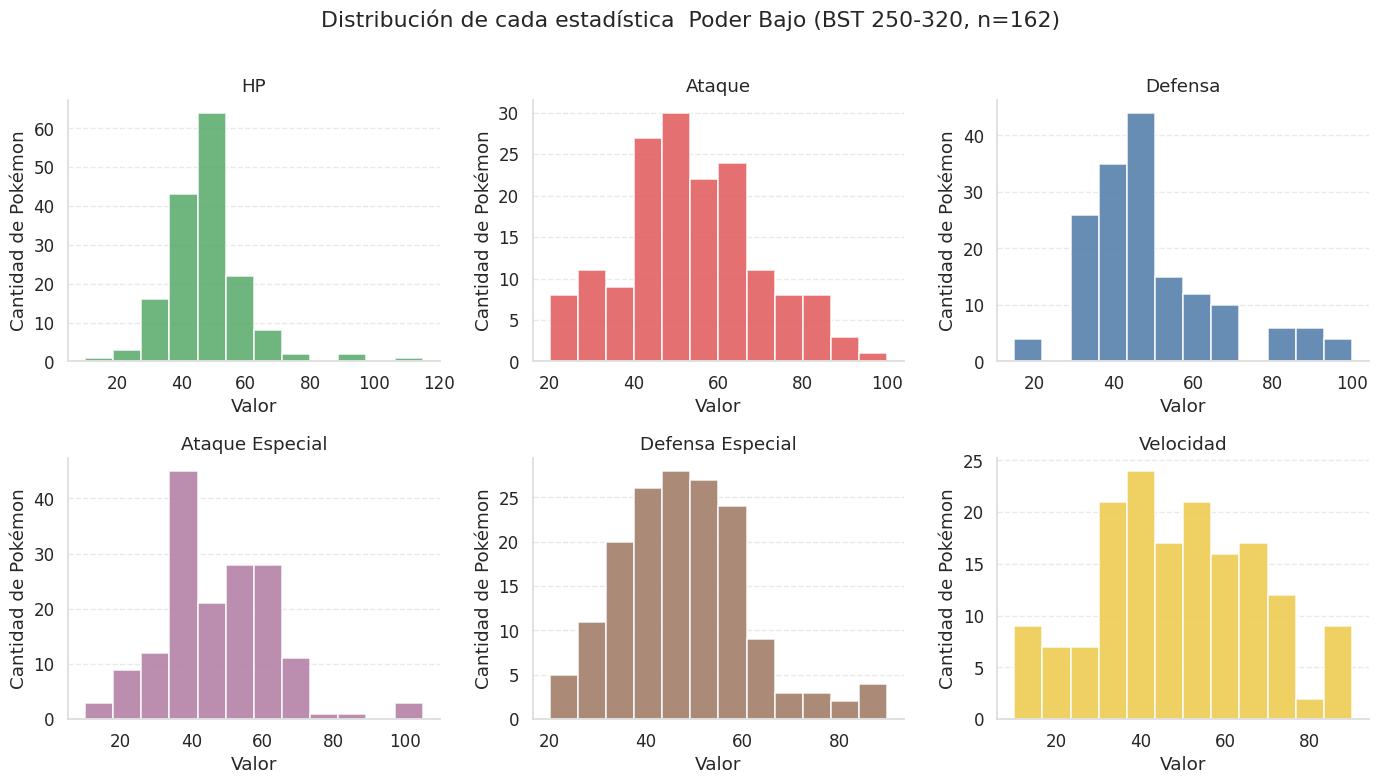

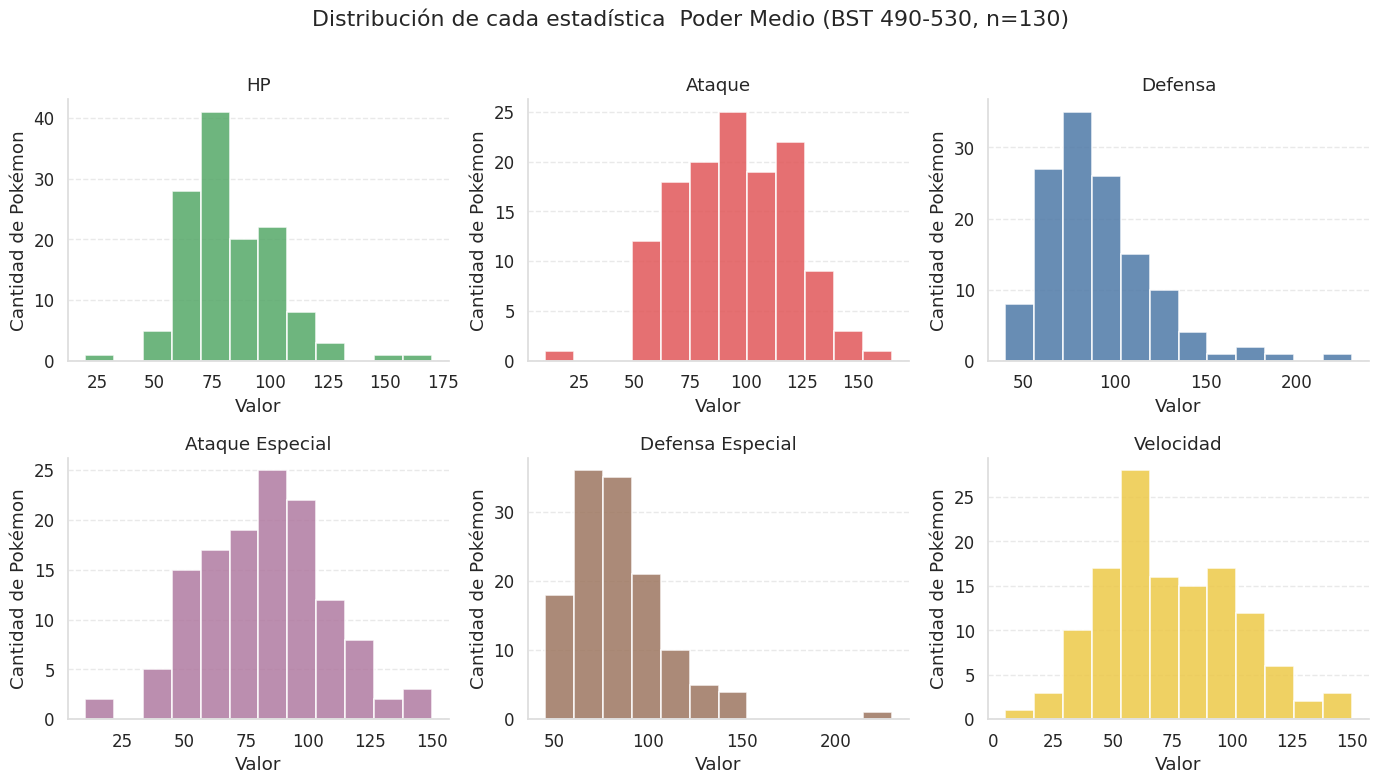

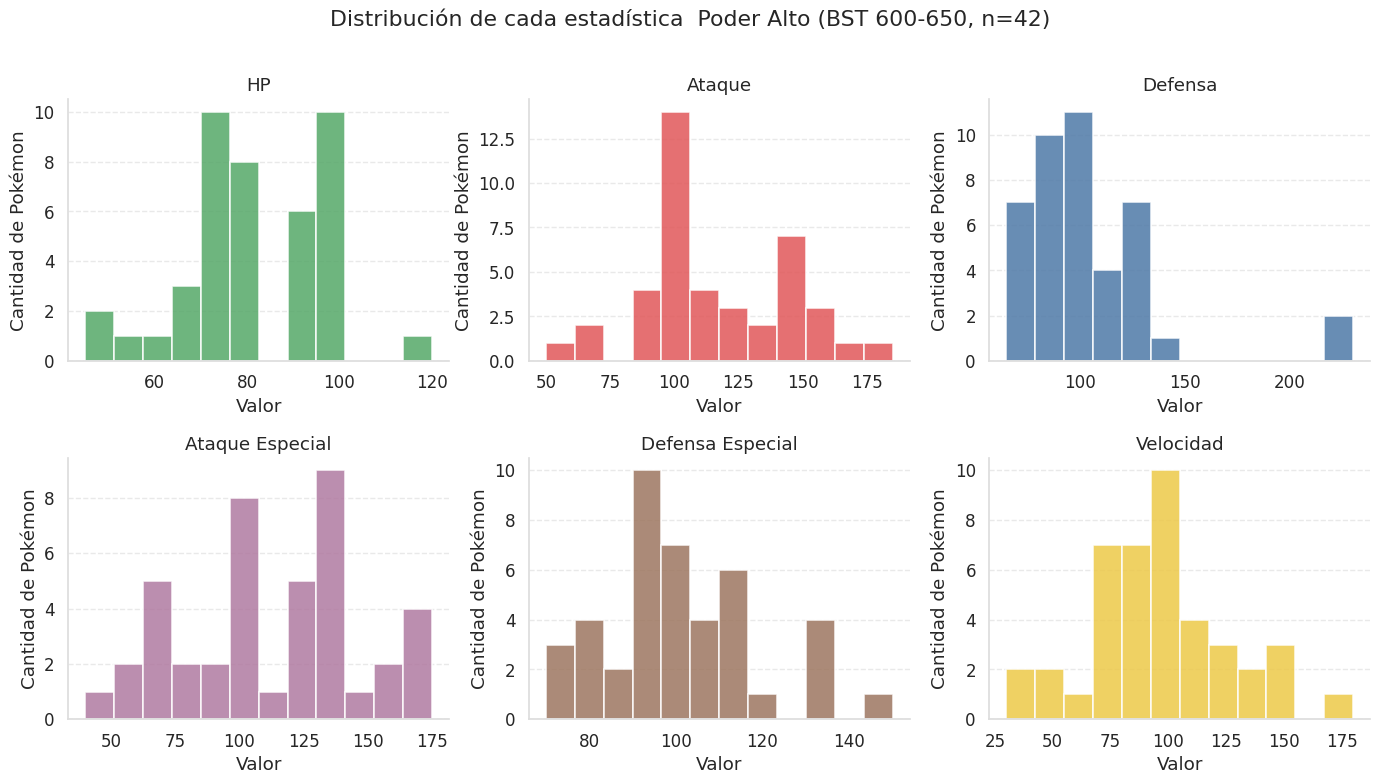

In [68]:
stats = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
LABELS = ['HP', 'Ataque', 'Defensa', 'Ataque Especial', 'Defensa Especial', 'Velocidad']
COLORS = ['#55A868', '#E15759', '#4E79A7', '#B07AA1', '#9D7660', '#EDC948']

bandas = [
    (250, 320, 'Bajo'),
    (490, 530, 'Medio'),
    (600, 650, 'Alto'),
]

for lo, hi, nivel in bandas:
    band = pokemon[(pokemon['base_total'] >= lo) & (pokemon['base_total'] <= hi)]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, (col, label, color) in enumerate(zip(stats, LABELS, COLORS)):
        axes[i].hist(band[col], bins=12, color=color, alpha=0.85, edgecolor='white', linewidth=1.2)
        axes[i].set_title(label)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Cantidad de Pokémon')

        axes[i].grid(axis='y', linestyle='--', alpha=0.7, color='#E0E0E0')
        axes[i].grid(axis='x', visible=False)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['left'].set_color('#DDDDDD')
        axes[i].spines['bottom'].set_color('#DDDDDD')

    fig.suptitle(f'Distribución de cada estadística  Poder {nivel} (BST {lo}-{hi}, n={len(band)})\n')

    plt.tight_layout()
    plt.show()

Al observar los histogramas agrupados por bandas de poder, se evidencia que tener un poder total similar no se traduce en estadísticas individuales similares. Dentro de un mismo rango de poder (bajo, medio o alto), las distribuciones de cada estadística son muy amplias y en varios casos presentan múltiples peaks, en lugar de agruparse estrechamente en torno a un único valor. Los Pokémon distribuyen sus valores de formas muy diversas, alcanzando extremos en ciertas características (como Ataque o Velocidad) a expensas de otras, lo que genera perfiles estadísticos completamente distintos a pesar de compartir la misma suma total.



# **Gráfico 12**

Para visualizar aún más esta diferencia de estadísticas de poder para 2 pokemon con el mismo poder total, usamos el caso de Shuckle con Honchkrow, ambos con un poder total de 505:

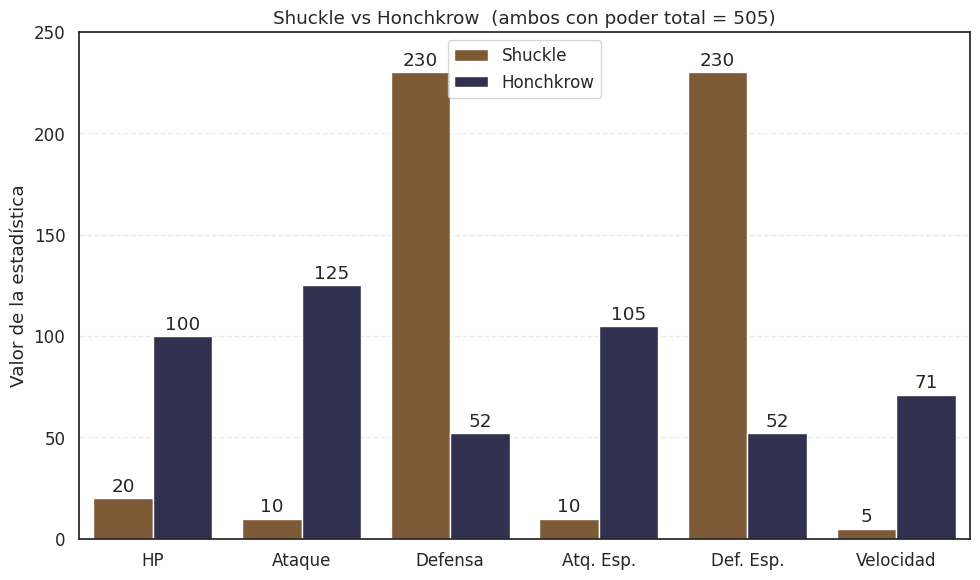

In [69]:
stats = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
STAT_LABELS = ['HP', 'Ataque', 'Defensa', 'Atq. Esp.', 'Def. Esp.', 'Velocidad']

nombres = ['Shuckle', 'Honchkrow']
sub = pokemon[pokemon['name'].isin(nombres)][['name'] + stats]

long_df = sub.melt(id_vars='name', value_vars=stats, var_name='estadistica', value_name='valor')
long_df['estadistica'] = long_df['estadistica'].map(dict(zip(stats, STAT_LABELS)))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=long_df, x='estadistica', y='valor', hue='name', ax=ax,
            palette={'Shuckle': '#8B5A2B', 'Honchkrow': '#2C2C54'})

for container in ax.containers:
    ax.bar_label(container, padding=2)

ax.set_xlabel("")
ax.set_ylabel("Valor de la estadística")
ax.set_ylim(0, 250)
ax.legend(title="", loc='upper center')
ax.set_title('Shuckle vs Honchkrow  (ambos con poder total = 505)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('caso_extremo_shuckle_honchkrow.png', dpi=160, bbox_inches='tight')
plt.show()

Se observa que Shuckle contiene casi la totalidad de su presupuesto de poder total en defensa y defensa especial (230 cada una) a costa de mantener el resto de sus atributos muy bajos (20 o menos). En contraste, Honchkrow distribuye sus puntos de forma relativamente similar en cada atributo. En este caso específico, se ilustra fuertemente que la igualdad en el poder total no asegura ninguna similitud en el comportamiento de sus atributos individuales.

# **¿Dos Pokémon con un poder total similar son necesariamente similares?**

**Conclusión**

Finalmente, podemos concluir que: **dos Pokémon con un poder total (BST) similar NO son necesariamente similares en atributos individuales.**

Los datos revelan que el poder total funciona simplemente como un 'presupuesto' que las especies distribuyen de maneras distintas mediante trade-offs estructurales. Al evaluar las distintas estadísticas de combate, la alta dispersión confirma que, bajo un mismo límite de poder total, las criaturas pueden especializarse en roles totalmente opuestos. El caso de Shuckle y Honchkrow es la prueba empírica de esto.

Evaluar la similitud en base a la suma total de su poder es engañoso, ya que la verdadera identidad de combate de un Pokémon radica en la especialización y distribución de sus atributos individuales.


# **Posible problema de Machine Learning**

**¿Qué intentaríamos predecir?** Si un Pokémon es legendario o no (is_legendary), a partir
de sus estadísticas de combate.

**¿Qué features usaríamos?** Las 6 estadísticas de combate (hp, attack, defense, sp_attack,
sp_defense, speed). Adicionalmento podríamos agregar generation, dado que la proporción de legendarios varía
bastante entre generaciones.

**¿Clasificación o regresión?** Clasificación binaria (is_legendary es 0 o 1).

**¿Qué del EDA sugiere que hay señal útil?** A partir del EDA encontramos que los legendarios concentran una
fracción alta de los valores extremos en varias estadísticas: 66.7% de los outliers superiores
en Defensa Especial, 60% en Ataque y Ataque Especial, pese a ser solo el 8.7% de la muestra.
Esto sugiere que los Pokémon legendarios destacan en las estadísticas de combate a diferencia de los que no.

**¿Qué dificultades anticipamos?**
- Clases desbalanceadas: solo 70 de 801 Pokémon (8.7%) son legendarios. Con pocas observaciones de la clase minoritaria para entrenar y validar con confianza.

- La proporción de legendarios varía mucho entre generaciones (3% en Gen 1 vs 21% en Gen 7),
  lo que podría afectar la capacidad de generalización si se entrena con unas generaciones y
  se prueba con otras.

# **Uso de herramientas de IA**

En este trabajo se utilizó la herramienta de inteligencia artificial Claude, con el fin de ser un apoyo para la construcción de diseños de gráficos de toda índole.